# Hirearchical 에이전트 시스템
- Hirearchical 에이전트 시스템은 Supervisor에이전트 시세틈의 확장버전. Supervisor를 갖는 여러 팀을 하위팀으로 구성하여, 하나의 조직 시스템을 만든다.
![scrennsh](./image/hierachical_agent.PNG)

팀단위로 여러 supervisor agent system을 두게되면, 각 팀마다 구분된 역할을 가지고 복잡한 작업을 수행할 수 있다.

openai function calling

https://platform.openai.com/docs/guides/function-calling

supervisor가 function calling을 통해 답변을 만들어 가는 과정.

이전에는 pydantic object를 통해 jsonoutputparser를 기반으로 답변을 해줬는데, 여기선 openai의 function calling을 이용한 것이다.

In [1]:
# 팟캐스트 생성하는 agent system을 생성하기 위함
# !pip install pydub

In [2]:
from dotenv import load_dotenv
load_dotenv()

True

### 웹 검색과 스크래핑 도구 설정
tavily_tool를 통해 찾아낸 url들의 원 page source, url안에 있는 모든 text들을 불러오는 작업을 한다.

In [3]:
from typing import Annotated, List
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.tools import tool

tavily_tool = TavilySearchResults(max_result=5)

@tool
def scrape_webpages(urls: List[str]) -> str:
    """Use requests and bs4 to scrape the provided web pages for detailed information."""
    loader = WebBaseLoader(urls)
    docs = loader.load()
    return "\n\n".join(
        [
            f"\n{doc.page_content}\n"
            for doc in docs
        ]
    )

USER_AGENT environment variable not set, consider setting it to identify your requests.


### OpenAI의 TTS API를 통한 TTS도구 설정

In [4]:
from langchain_core.tools import tool
from openai import OpenAI
from pathlib import Path

@tool
def text_to_speech(text: str, voice: str, output_filename: str) -> str:
    """
    Converts text to speech using OpenAI's TTS API, saving the audio file locally with a dynamic filename.

    Args:
        text (str): The text to convert to speech.
        voice (str): The voice model to use for speech synthesis. Options include:
                     - 'alloy', 'echo', 'fable', 'onyx', 'nova', 'shimmer'.
        output_filename (str): The name for the output audio file, including file extension (e.g., 'output.mp3').

    Returns:
        str: The path to the saved audio file.
    """
    client = OpenAI()
    speech_file_path = Path(output_filename)
    response = client.audio.speech.create(model="tts-1-hd", voice=voice, input=text)
    response.stream_to_file(speech_file_path)
    return str(speech_file_path)

### 주어진 여러 segment별 오디오 트랙을 하나의 오디오 파일로 만드는 도구 설정.
host와 guest사이에서 특정 주제에 대해 이야기를 나누는데, 이것을 만들어주기 위해선, 하나의 오디오파일을 통해서 만들수 없다

호스트가 말하는부분, 게스트가 말하는부분을 이어 붙여서 하나의 팟캐스트를 만들어야한다.

`segments` : 호스트와 게스트 각각의 오디오 파일들을 받아주는 입력값이다.

`pauses_between_segments` : 각각의 오디오 파일을 생성하는 과정에서 중간중간 텀을 줘야 자연스러운 대화가 이뤄진다.

`output_filename` : 하나의 오디오 파일을 냈을때, 이름.

In [ ]:
from langchain_core.tools import tool
from pydub import AudioSegment
from typing import List

@tool
def edit_podcast_audio(segments: List[str], pauses_between_segments: int = 100, output_filename: str = "final_podcast_episode.mp3") -> str:
    """
    Edits a podcast episode by combining audio segments with specified pauses between them, ensuring consistent volume.

    Args:
        segments (List[str]): List of paths to audio segment files.
        pauses_between_segments (int): Duration of pause between segments in milliseconds. Default is 1000.
        output_filename (str): The name for the output podcast file, including file extension (e.g., 'episode.mp3').

    Returns:
        str: The path to the saved podcast episode.
    """
    # AudioSegment: Audio파일을 다루는 AudioSegment. silent를 통해 무음구간을 만들어준다.
    podcast_episode = AudioSegment.silent(duration=0) 

    # 여러개의 오디오 파일을 segment로 저장
    for segment_path in segments:
        segment = AudioSegment.from_file(segment_path)
        podcast_episode += AudioSegment.silent(duration=pauses_between_segments) + segment # 무음구간 + segment

    podcast_episode = podcast_episode.normalize()
    podcast_episode.export(output_filename, format='mp3')

    return output_filename

c:\Users\skyop\AppData\Local\pypoetry\Cache\virtualenvs\langchain-kr-gLkynrUQ-py3.11\Lib\site-packages\pydub\utils.py:170: RuntimeWarning: Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work
  warn("Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work", RuntimeWarning)


### 도구 리스트 정의

In [6]:
tools = [
    tavily_tool, # research : built-in search tool via Tavily
    scrape_webpages, # research
    text_to_speech, # podcast : out custom text to speech tool
    edit_podcast_audio # podcast  : Audio mix tool
]

### 하위 에이전트와 supervisor 에이전트 설정 함수 정의

In [7]:
from typing import List, Optional
from langchain.output_parsers.openai_functions import JsonOutputFunctionsParser
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_openai import ChatOpenAI

from langgraph.graph import StateGraph, END, START, add_messages
from langchain_core.messages import HumanMessage

def agent_node(state, agent, name):
    result = agent.invoke(state)
    return {"messages": [HumanMessage(content=result["messages"][-1].content, name=name)]}

def create_team_supervisor(llm: ChatOpenAI, system_prompt, members) -> str:
    """An LLM-based router."""
    
    options = ["FINISH"] + members # supervisor가 다음으로 수행할 노드가 어디일지 선택지. 라우팅할 노드 설정이다.
    # openai의 function calling을 만들기 위한 json이다. 
    # 이전에는 pydantic object를 통해 jsonoutputparser를 기반으로 답변을 해줬는데, 여기선 openai의 function calling을 이용한 것이다.
    function_def = {
        "name": "route",
        "description": "Select the next role.",
        "parameters": {
            "title": "routeSchema",
            "type": "object",
            "properties": {
                "next":{ # key값
                    "title": "Next",  # value값
                    "anyOf": [
                   {"enum": options} 
                    ],
                }
            },
            "required": ["next"] # key값인 next가 반드시 필요하다.
        }
    }
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", system_prompt),
            MessagesPlaceholder(variable_name="messages"),
            (
                "system",
                "Given the conversation above, who should act next?"
                " Or should we FINISH? Select one of: {options}",
            )
        ]
    ).partial(options=str(options), team_members=", ".join(members))
    return (
        prompt| llm.bind_functions(functions=[function_def], function_call="route")|JsonOutputFunctionsParser()
    )


### Research Team 구성하기

In [8]:
import functools
import operator
from typing_extensions import TypedDict

from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import create_react_agent
from langgraph.graph import add_messages
class ResearchTeamState(TypedDict):
    messages: Annotated[List[BaseMessage], operator.add]
    #messages: Annotated[List[BaseMessage], add_messages]
    team_members: List[str]
    next: str # supervisor agent가 다음에 수행할 노드가 무엇인지 정의.

llm = ChatOpenAI(model="gpt-4o-mini")

# Search
search_system = """
You are a search specialist in a research team. 
Your role is to use the Tavily search tool to find relevant and up-to-date information on the given topic to generate the podcast.

Your tasks:
1. Analyze the user's request or question.
2. Formulate effective search queries based on the request.
3. Use the Tavily search tool to find information.
4. Summarize the most relevant findings concisely.
5. If the search results are insufficient, consider refining your search query and trying again.

Always strive for accuracy and relevance in your search results. 
If you can't find satisfactory information, be honest about the limitations of your search.
"""
search_agent = create_react_agent(llm, tools=[tavily_tool], state_modifier=search_system)
search_node = functools.partial(agent_node, agent=search_agent, name="Search")

# Webscraper_system
webscraper_system = """
You are a web scraping specialist in a research team. 
Your role is to extract detailed information from specific web pages using the scrape_webpages tool.

Your tasks:
1. Analyze the URLs or web pages provided, usually as a result of the Search agent's findings.
2. Use the scrape_webpages tool to extract relevant content from these pages.
3. Process and summarize the scraped content, focusing on the most pertinent information related to the research topic.
4. If the scraped content is not satisfactory, consider requesting different URLs from the Search agent or suggesting refinements to the search query.

Ensure that you respect website terms of service and ethical scraping practices. Always summarize and contextualize the information you scrape, don't just return raw data.
"""

research_agent = create_react_agent(llm, tools=[scrape_webpages], state_modifier=webscraper_system)

research_node = functools.partial(agent_node, agent=research_agent, name="WebScraper")

supervisor_agent = create_team_supervisor(
    llm,
    "You are a supervisor tasked with managing a conversation between the"
    " following workers:  Search, WebScraper. Given the following user request,"
    " respond with the worker to act next. Each worker will perform a"
    " task and respond with their results and status. When finished,"
    " respond with FINISH.",
    ["Search", "WebScraper"],
)

C:\Users\skyop\AppData\Local\Temp\ipykernel_19820\741832146.py:48: LangChainDeprecationWarning: The method `BaseChatOpenAI.bind_functions` was deprecated in langchain-openai 0.2.1 and will be removed in 0.3.0. Use :meth:`~langchain_openai.chat_models.base.ChatOpenAI.bind_tools` instead.
  prompt| llm.bind_functions(functions=[function_def], function_call="route")|JsonOutputFunctionsParser()


In [9]:
research_graph = StateGraph(ResearchTeamState)
research_graph.add_node("Search", search_node)
research_graph.add_node("WebScraper", research_node)
research_graph.add_node("supervisor", supervisor_agent)

research_graph.add_edge("Search", "supervisor")
research_graph.add_conditional_edges(
    "supervisor",
    lambda x: x["next"],
    {"Search": "Search", "WebScraper": "WebScraper", "FINISH": END},
)
research_graph.add_edge(START, "supervisor")
chain = research_graph.compile()

In [10]:
# The following functions interoperate between the top level graph state
# and the state of the research sub-graph
# this makes it so that the states of each graph don't get intermixed


# 상위레이어와 하위레이어 supervisor간의 state결과물을 공유하기 위한 체인 정의. 
# 하위레이어는, 상위레이어가 가지고 있는 state값을 받아와야한다.
def enter_chain(message: str):
    results = {
        "messages": [HumanMessage(content=message)],
    }
    return results


research_chain = enter_chain | chain

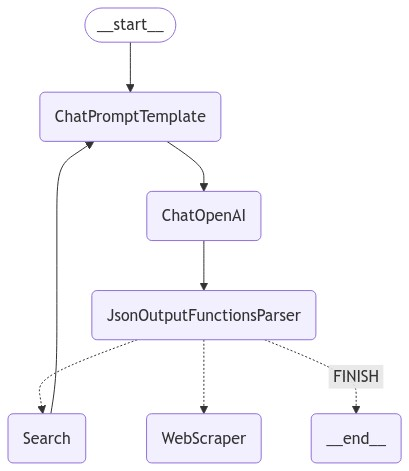

In [11]:
from IPython.display import Image, display

display(Image(chain.get_graph(xray=True).draw_mermaid_png()))

### PodcastTeam 그래프 상태

In [12]:
# PodcastTeam 그래프 상태
class PodcastTeamState(TypedDict):
    messages: Annotated[List[BaseMessage], operator.add]
    team_members: List[str]
    next: str
    script: List[dict] # 오디오 파일을 생성하기 이전에 텍스트 형태의 문장
    audio_segments: List[str] # TTS로 오디오 파일을 만들어주기 위함

podcast_plan_system="""
You are tasked with creating a structured script for a podcast episode. 
The script should consist of a series of interactions between the host and the guest based on the provided topic and information from the research.
IMPORTANT NOTE: The podcast should have 2 or more speakers to have a conversation.

For each part of the dialogue, clearly specify whether it's the host speaking or the guest. Also, assign a suitable voice model for text-to-speech conversion for each segment. Use the following voice models based on the character:

- Host segments: Use the 'alloy' voice model.
- Guest segments: Use the 'fable' voice model.

The output should be a list where each item is a dictionary with keys 'speaker', 'text', and 'voice', indicating the speaker (host or guest), their line of dialogue, and the voice model to use.

Example output format:
[
    {"speaker": "host", "text": "Welcome to our podcast, where we explore the latest in technology.", "voice": "alloy"},
    {"speaker": "guest", "text": "Thank you for having me, it's great to be here to share my experiences.", "voice": "fable"},
    {"speaker": "host", "text": "Can you tell us about your current project?", "voice": "alloy"},
    {"speaker": "guest", "text": "Certainly! I've been working on a new AI platform that...", "voice": "fable"},
    ...
]

Your task is to generate a similar structured script in **KOREAN**,
ensuring each dialogue segment between the host and guest is well-defined and allocates the appropriate voice model for the text-to-speech conversion process.

"""
podcast_planner_agnet = create_react_agent(
    llm, state_modifier=podcast_plan_system, tools=[tavily_tool]
)
podcast_planner_node = functools.partial(agent_node, agent=podcast_planner_agnet, name="PodcastPlanner")

# AudioProducer 에이전트
audio_producer_system="""
You are responsible for producing the final audio for the podcast episode. 
Take the structured script provided by the Podcast Planner, which contains segments marked with 'speaker' (either 'host' or 'guest'), the 'text' for each segment, and the 'voice' model to use.

For each segment, use the 'text_to_speech' tool to generate audio, specifying the 'text' and 'voice' as provided. 
Ensure each segment is saved as a separate audio file.

After generating all segments, use the 'edit_podcast_audio' tool to combine these audio files into one seamless podcast episode. 
The audio files should be combined in the order they are provided in the script, with appropriate pauses between segments to simulate a natural conversation flow.

Your output should be the path to the final combined podcast episode audio file.
"""

# AudioProducer 에이전트: TTS를 수행하고, 하나의 팟캐스트 오디오 파일로 만들어주는다.
audio_producer_agent = create_react_agent(
    llm,
    [text_to_speech, edit_podcast_audio], state_modifier=audio_producer_system
)
audio_producer_node = functools.partial(agent_node, agent=audio_producer_agent, name="AudioProducer")

# 팀 감독자 생성
podcast_supervisor = create_team_supervisor(
    llm,
    """You are a supervisor tasked with managing the podcast creation process.
    Your team consists of a PodcastPlanner and an AudioProducer.
    Given the current state, decide which team member should act next or if the process is complete.
    Respond with 'PodcastPlanner', 'AudioProducer', or 'FINISH'.""",
    ["PodcastPlanner", "AudioProducer"]
)

### Podcast Team 그래프 및상위 레이어와의 연결 Chain 정의

In [13]:
podcast_graph = StateGraph(PodcastTeamState)
podcast_graph.add_node("PodcastPlanner", podcast_planner_node)
podcast_graph.add_node("AudioProducer", audio_producer_node)
podcast_graph.add_node("supervisor", podcast_supervisor)

# 제어 흐름 정의
podcast_graph.add_edge("PodcastPlanner", "supervisor")
podcast_graph.add_edge("AudioProducer", "supervisor")
podcast_graph.add_conditional_edges(
    "supervisor",
    lambda x: x["next"],
    {"PodcastPlanner": "PodcastPlanner", "AudioProducer": "AudioProducer", "FINISH": END},
)
podcast_graph.add_edge(START, "supervisor")

chain = podcast_graph.compile()

# 상위 레벨 그래프 상태와 팟캐스트 서브그래프 상태 간의 상호 운용을 위한 함수
def enter_chain(message: str):
    results = {
        "messages": [HumanMessage(content=message)],
        "team_members": ["PodcastPlanner", "AudioProducer"],
        "next": "",
        "script": [],
        "audio_segments": []
    }
    return results

podcast_chain = enter_chain | chain

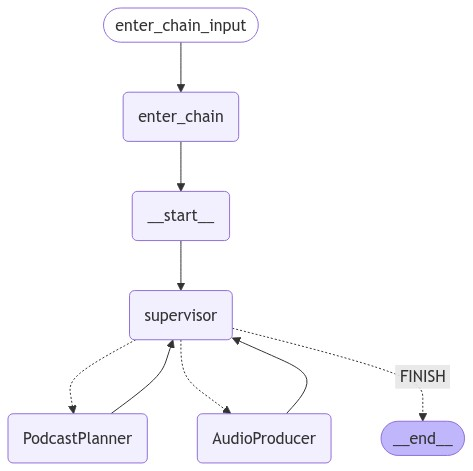

In [14]:
from IPython.display import Image, display

display(Image(podcast_chain.get_graph().draw_mermaid_png()))

### 상위 레이어의 Supervisor정의하기


In [15]:
from langchain_core.messages import BaseMessage
from langchain_openai.chat_models import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini")

supervisor_node = create_team_supervisor(
    llm,
    "You are a supervisor tasked with managing a conversation between the"
    " following teams: {team_members}. Given the following user request,"
    " respond with the worker to act next. Each worker will perform a"
    " task and respond with their results and status. When finished,"
    " respond with FINISH.",
    ["ResearchTeam", "PodcastTeam"],
)

### 상위 레이어 그래프 구축하기

In [16]:
# Top-level graph state
class State(TypedDict):
    messages: Annotated[List[BaseMessage], operator.add]
    next: str


def get_last_message(state: State) -> str:
    return state["messages"][-1].content


def join_graph(response: dict):
    return {"messages": [response["messages"][-1]]}


# Define the graph.
super_graph = StateGraph(State)
# First add the nodes, which will do the work
super_graph.add_node("ResearchTeam", get_last_message | research_chain | join_graph)
super_graph.add_node(
    "PodcastTeam", get_last_message | podcast_chain | join_graph
)
super_graph.add_node("supervisor", supervisor_node)

# Define the graph connections, which controls how the logic
# propagates through the program
super_graph.add_edge("ResearchTeam", "supervisor")
super_graph.add_edge("PodcastTeam", "supervisor")
super_graph.add_conditional_edges(
    "supervisor",
    lambda x: x["next"],
    {
        "PodcastTeam": "PodcastTeam",
        "ResearchTeam": "ResearchTeam",
        "FINISH": END,
    },
)
super_graph.add_edge(START, "supervisor")
super_graph = super_graph.compile()

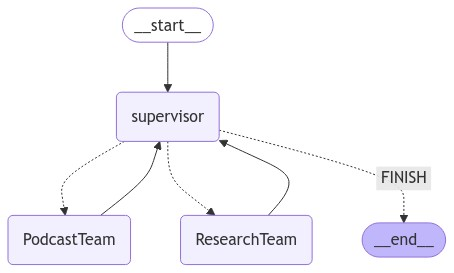

In [17]:
from IPython.display import Image, display

display(Image(super_graph.get_graph().draw_mermaid_png()))

In [ ]:
for s in super_graph.stream(
    {
        "messages": [
            HumanMessage(
                content="OpenAI가 최근에 출시한 o1 모델과 AI 에이전트"
            )
        ],
    },
    {"recursion_limit": 150},
):
    if "__end__" not in s:
        print(s)
        print("---")

{'supervisor': {'next': 'ResearchTeam'}}
---
{'ResearchTeam': {'messages': [HumanMessage(content='### Summary of OpenAI\'s Recent Releases: o1 Model and AI Agents\n\n#### OpenAI o1 Model\nOpenAI has launched the **o1 model**, also referred to as the **Strawberry model**, marking a significant advancement in AI capabilities, particularly in reasoning and problem-solving. Key highlights include:\n\n1. **Enhanced Reasoning Abilities**: The o1 model excels in handling complex tasks, such as coding and mathematics, with improved accuracy compared to previous models like GPT-4o. It can explain its reasoning while solving problems, which is a pivotal shift toward more human-like intelligence (The Verge, TechCrunch).\n\n2. **Self-Fact-Checking**: A distinctive feature of o1 is its self-fact-checking ability, allowing it to analyze multiple aspects of a question before answering, thereby reducing errors that are typically seen in generative AI (TechCrunch).\n\n3. **Performance Metrics**: In com

C:\Users\skyop\AppData\Local\Temp\ipykernel_19820\3661896293.py:22: DeprecationWarning: Due to a bug, this method doesn't actually stream the response content, `.with_streaming_response.method()` should be used instead
  response.stream_to_file(speech_file_path)
C:\Users\skyop\AppData\Local\Temp\ipykernel_19820\3661896293.py:22: DeprecationWarning: Due to a bug, this method doesn't actually stream the response content, `.with_streaming_response.method()` should be used instead
  response.stream_to_file(speech_file_path)
C:\Users\skyop\AppData\Local\Temp\ipykernel_19820\3661896293.py:22: DeprecationWarning: Due to a bug, this method doesn't actually stream the response content, `.with_streaming_response.method()` should be used instead
  response.stream_to_file(speech_file_path)
C:\Users\skyop\AppData\Local\Temp\ipykernel_19820\3661896293.py:22: DeprecationWarning: Due to a bug, this method doesn't actually stream the response content, `.with_streaming_response.method()` should be used 

{'PodcastTeam': {'messages': [HumanMessage(content="It seems that I am encountering persistent issues with saving the final podcast episode due to directory errors. Unfortunately, without the ability to create or access the specified directories, I won't be able to successfully generate the final audio file.\n\nTo resolve this, please ensure that the directory exists or try running the process in a different environment where you can manage the file paths directly. If you have suggestions for how to proceed or if you'd like to specify an alternative method, please let me know!", additional_kwargs={}, response_metadata={}, name='AudioProducer')]}}
---
{'supervisor': {'next': 'PodcastTeam'}}
---


C:\Users\skyop\AppData\Local\Temp\ipykernel_19820\3661896293.py:22: DeprecationWarning: Due to a bug, this method doesn't actually stream the response content, `.with_streaming_response.method()` should be used instead
  response.stream_to_file(speech_file_path)
c:\Users\skyop\AppData\Local\pypoetry\Cache\virtualenvs\langchain-kr-gLkynrUQ-py3.11\Lib\site-packages\pydub\utils.py:198: RuntimeWarning: Couldn't find ffprobe or avprobe - defaulting to ffprobe, but may not work
  warn("Couldn't find ffprobe or avprobe - defaulting to ffprobe, but may not work", RuntimeWarning)
c:\Users\skyop\AppData\Local\pypoetry\Cache\virtualenvs\langchain-kr-gLkynrUQ-py3.11\Lib\site-packages\pydub\utils.py:198: RuntimeWarning: Couldn't find ffprobe or avprobe - defaulting to ffprobe, but may not work
  warn("Couldn't find ffprobe or avprobe - defaulting to ffprobe, but may not work", RuntimeWarning)
c:\Users\skyop\AppData\Local\pypoetry\Cache\virtualenvs\langchain-kr-gLkynrUQ-py3.11\Lib\site-packages\pydu